# Primera parte del proyecto vamos a usar SRV.
Para poder predecir el tipo de cambio y la tasa de interes

## Librerías que vamos a usar en el proyecto

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

In [ ]:
# lectura de los  datos y remplazamos , y _
proyecto_df = pd.read_excel('/content/data set Proyecto Final.xlsx')
proyecto_df.columns = proyecto_df.columns.str.strip().str.replace(',', '').str.replace(' ', '_').str.lower()
proyecto_df.head()

,desaño,desmes,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
0,2010.07,Jul.,4282081,152699,1544051,5660828,2220797,3837388,259273,1249680,3.934824,29.605238
1,2010.08,Ago.,4359798,153111,1550875,5703148,2259947,4014747,260441,1259990,3.937610,28.910476
2,2010.09,Set.,4005438,167185,886653,7049683,2247213,4597633,239637,1164202,3.951891,29.332273
3,2010.10,Oct.,4062383,168583,897503,7140713,2315940,4832333,250494,1193453,3.956984,29.608421
4,2010.11,Nov.,4127584,172567,906275,7226265,2411831,5125575,268533,1241870,3.967600,30.543810


In [ ]:
proyecto_df.describe()

,desaño,h_construccion_$,h_refaccion_$,h_adquisición_nueva_$,h_adquisición_resto_$,h_otros_$,p_automotores_$,p_maquinarias_$,p-otros$,tipo_de_cambio,tasa_de_interes
count,189.000000,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,189.000000,189.000000
mean,2017.938254,2.621550e+07,3.771733e+06,2.095437e+08,1.195724e+08,8.430568e+07,2.695213e+08,3.864622e+07,1.174013e+08,206.279592,53.790515
std,4.571042,5.475953e+07,7.470863e+06,5.686017e+08,3.243851e+08,2.378353e+08,6.325560e+08,8.426171e+07,2.790139e+08,390.162329,22.553534
min,2010.070000,2.207474e+06,1.526990e+05,8.866530e+05,5.660828e+06,2.220797e+06,3.837388e+06,2.396370e+05,1.164202e+06,3.934824,28.910476
25%,2014.060000,3.412578e+06,1.044559e+06,9.047150e+06,9.373211e+06,5.202887e+06,1.706154e+07,1.137943e+06,4.165550e+06,8.125515,37.498182
50%,2018.050000,9.000642e+06,2.045756e+06,9.263400e+07,2.957281e+07,1.550378e+07,4.445133e+07,6.112407e+06,8.479135e+06,23.668748,46.034737
75%,2022.040000,2.753194e+07,2.787504e+06,1.178265e+08,3.889502e+07,2.740872e+07,9.191814e+07,2.277430e+07,5.562232e+07,113.334474,67.652273
max,2026.030000,3.258690e+08,4.039955e+07,3.461931e+09,1.465120e+09,1.232587e+09,2.791996e+09,3.859431e+08,1.168717e+09,1449.334662,138.748947


In [ ]:
proyecto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   desaño                 189 non-null    float64
 1   desmes                 189 non-null    object 
 2   h_construccion_$       189 non-null    int64  
 3   h_refaccion_$          189 non-null    int64  
 4   h_adquisición_nueva_$  189 non-null    int64  
 5   h_adquisición_resto_$  189 non-null    int64  
 6   h_otros_$              189 non-null    int64  
 7   p_automotores_$        189 non-null    int64  
 8   p_maquinarias_$        189 non-null    int64  
 9   p-otros$               189 non-null    int64  
 10  tipo_de_cambio         189 non-null    float64
 11  tasa_de_interes        189 non-null    float64
 12  cluster                189 non-null    int32  
dtypes: float64(3), int32(1), int64(8), object(1)
memory usage: 18.6+ KB


In [ ]:
# seleccionamos las variables regresoras.

proyecto_tc = [col for col in proyecto_df.columns if col not in ["desaño", 'desmes',	"tipo_de_cambio",	"tasa_de_interes"]]
X = proyecto_df[proyecto_tc]

# Definimos nuestra Variables objetivos en este caso dos

y = proyecto_df[['tipo_de_cambio','tasa_de_interes']]


In [ ]:
# Dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hasta aqui datos y codigos que vamos a usar a nivel general

In [ ]:
# Scalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# svr multisalida usando MultiOutputRegressor
# juntamos el SRV dentro del MultiOutputRegressor

base_svr = SVR()
multi_svr = MultiOutputRegressor(base_svr)


In [ ]:
# parametros para GridSearchCV y buscar el mejor modelo
param_grid = {
    'estimator__kernel': ['linear', 'rbf'],
    'estimator__C': [10, 100],
    #'estimator__gamma': ["scale", "auto"]
}
grid_search = GridSearchCV(multi_svr, param_grid, cv=3, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=MultiOutputRegressor(estimator=SVR()),
             param_grid={'estimator__C': [10, 100],
                         'estimator__kernel': ['linear', 'rbf']},
             scoring='r2')

In [ ]:
# Evaluamos el mejor modelo
best_model  = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

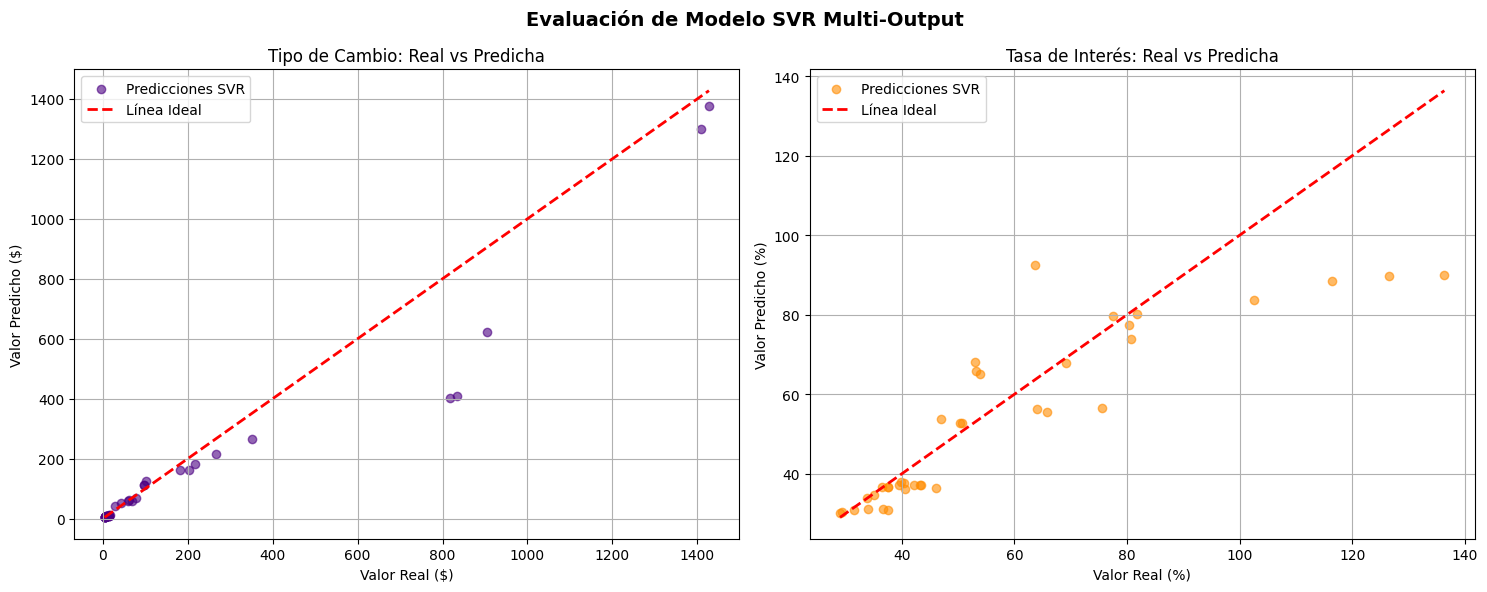

In [ ]:
# Configuramos el grafico

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Tipo de Cambio (Primera columna de la matriz: índice 0)
ax1.scatter(y_test.iloc[:, 0], y_pred[:, 0], color='indigo', alpha=0.6, label='Predicciones SVR')
ax1.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()],
         [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'r--', lw=2, label='Línea Ideal')
ax1.set_title('Tipo de Cambio: Real vs Predicha')
ax1.set_xlabel('Valor Real ($)')
ax1.set_ylabel('Valor Predicho ($)')
ax1.grid(True)
ax1.legend()

# Tasa de Interés (Segunda columna de la matriz: índice 1)

ax2.scatter(y_test.iloc[:, 1], y_pred[:, 1], color='darkorange', alpha=0.6, label='Predicciones SVR')
ax2.plot([y_test.iloc[:, 1].min(), y_test.iloc[:, 1].max()],
         [y_test.iloc[:, 1].min(), y_test.iloc[:, 1].max()], 'r--', lw=2, label='Línea Ideal')
ax2.set_title('Tasa de Interés: Real vs Predicha')
ax2.set_xlabel('Valor Real (%)')
ax2.set_ylabel('Valor Predicho (%)')
ax2.grid(True)
ax2.legend()

plt.suptitle('Evaluación de Modelo SVR Multi-Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Los puntos en la tasa de interes estan mas dispersos que en de tipo de cambio, se puede concluir que que el volumen de creditos tienen mayor correlacion y predictibilidad sobre el tipo de cambio que sobre el tasa de interes.

In [ ]:
# vamos a probar el modelo con nuevos datos
# ingresamos nuevos datos
nuevos_datos_credito = {

    "h_construccion_$": 172938217.5,      # Monto estimado para Construcción
    "h_refaccion_$": 26034760.5,          # Monto para Refacción
    "h_adquisición_nueva_$": 1452700721.00,# Compra Vivienda Nueva
    "h_adquisición_resto_$": 1205027010.33,# Compra Vivienda Usada
    "h_otros_$": 842888983.00,             # Otros créditos hipotecarios
    "p_automotores_$": 2211667820.75,      # Préstamos prendarios autos
    "p_maquinarias_$": 305978956.5,       # Préstamos prendarios Maquinaria
    "p-otros$": 1152284868.67              # Resto de los prestamos prendarios
}

In [ ]:
# Convertimos los datos nuevos en un data frame, scalamos y realziamos la prediccion
entrada_nueva = pd.DataFrame([nuevos_datos_credito])
entrada_nueva_scaled = scaler.transform(entrada_nueva)
prediccion = best_model.predict(entrada_nueva_scaled)

In [ ]:
# captamos lo predicho
t_cambio_predicha = prediccion[0][0]
t_interes_predicha = prediccion[0][1]

In [ ]:
# realizamos una salida de la prediccion
print(f"\n Variables de Entrada Procesadas (Volumen de Crédito Solicitado).")
print(f"Predicción de las variables seleccionadas del Modelo SVR:")
print(f"      -> Tipo de Cambio Estimado:  ${t_cambio_predicha:.2f} ARS")
print(f"      -> Tasa de Interés Estimada:  {t_interes_predicha:.2f}%")
print("-" * 60)

# Lógica de decisión sugerida para la entrega
if t_interes_predicha > 65.0: # podemos modificar la tasa de interes que queremos marcar como linea de estres.
    print("RECOMENDACIÓN: ALERTA. Las tasas proyectadas superan el 65%.")
    print("Acción a tomar: Congelar colocación de préstamos a tasa fija y exigir mayores garantías.")
else:
    print("RECOMENDACIÓN: ESCENARIO MODERADO. Tasas proyectadas bajo el umbral de riesgo.")
    print("Acción a tomar: Mantener la liquidez activa y promover líneas hipotecarias y prendarias cortas.")





 Variables de Entrada Procesadas (Volumen de Crédito Solicitado).
Predicción de las variables seleccionadas del Modelo SVR:
      -> Tipo de Cambio Estimado:  $1253.30 ARS
      -> Tasa de Interés Estimada:  70.46%
------------------------------------------------------------
RECOMENDACIÓN: ALERTA. Las tasas proyectadas superan el 65%.
Acción a tomar: Congelar colocación de préstamos a tasa fija y exigir mayores garantías.


# Predecimos los montos de creditos de acuerdo al tipo de cambio tasa de interes.
Para esta seccion usamos  

# Arbol de dicisión.

In [ ]:
# partiendo de algunas partes generales vamos a continuar desde alli
# Definimos nuetra variable regresora
R = proyecto_df[['tipo_de_cambio','tasa_de_interes']]
# definimos nuetras variables objetivos en este caso las de los creditos
q = proyecto_df[proyecto_tc]

In [ ]:
# dividimos los datos de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(R, q, test_size=0.2, random_state=42)

In [ ]:
# Scalamos los datos
scaler_2 = StandardScaler()
X_train_scaled = scaler_2.fit_transform(X_train)
X_test_scaled = scaler_2.transform(X_test)

In [ ]:
model_tree = DecisionTreeRegressor(random_state=42)
multi_tree = MultiOutputRegressor(model_tree)

In [ ]:
# paramnetros de GridSearchCV
param_grid2 = {
    'estimator__max_depth': [3,5,10,None],
    'estimator__min_samples_split': [2, 5, 10],
}

In [ ]:

grid_search2 = GridSearchCV(multi_tree, param_grid2, cv=5, scoring='neg_mean_squared_error')
grid_search2.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=MultiOutputRegressor(estimator=DecisionTreeRegressor(random_state=42)),
             param_grid={'estimator__max_depth': [3, 5, 10, None],
                         'estimator__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [ ]:
# Evaluamos el mejor modelo
mejor_modelo_tree = grid_search2.best_estimator_
y_pred = mejor_modelo_tree.predict(X_test_scaled)

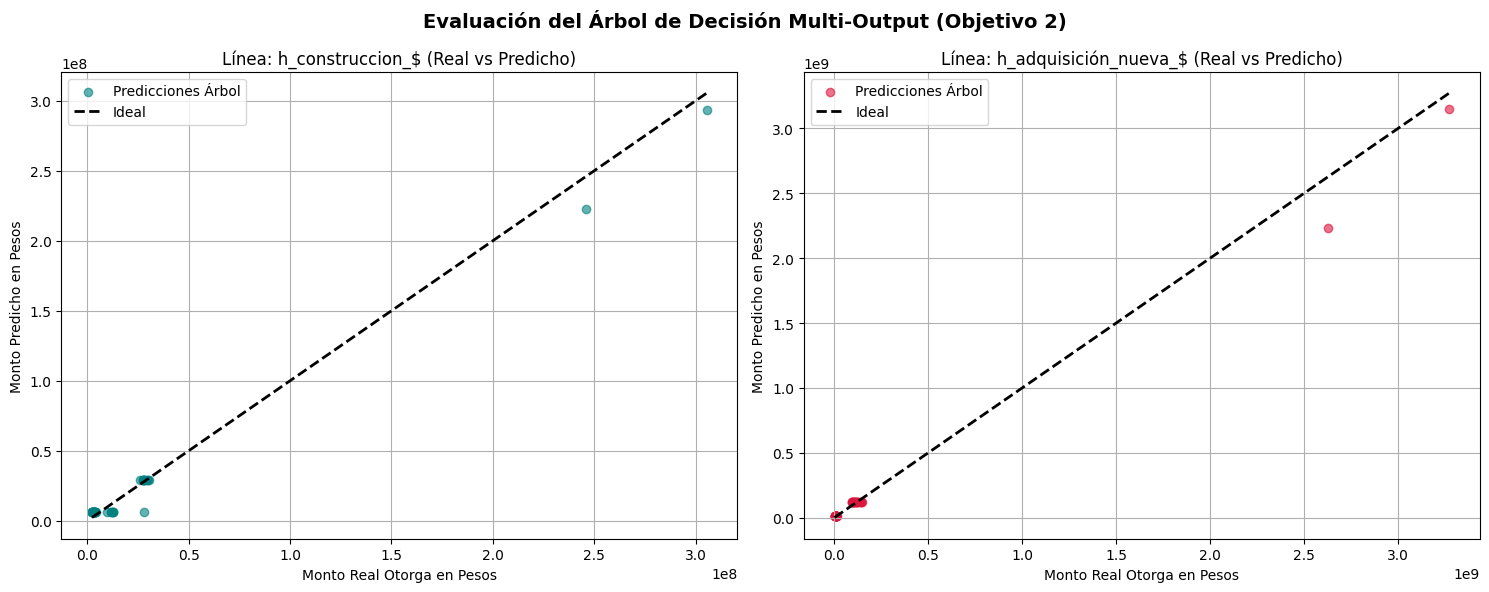

  DESEMPEÑO DEL MODELO    
R² Score para [h_construccion_$]: 0.9887
R² Score para [h_refaccion_$]: 0.9952
R² Score para [h_adquisición_nueva_$]: 0.9891
R² Score para [h_adquisición_resto_$]: 0.9997
R² Score para [h_otros_$]: 0.9935
R² Score para [p_automotores_$]: 0.9953
R² Score para [p_maquinarias_$]: 0.9959
R² Score para [p-otros$]: 0.9981


In [ ]:
# Graficamos 2 de las líneas más importantes para no saturar la pantalla: Construcción e Hipotecarios Adquision Nuevos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Grafico 1: Créditos para Construcción (Columna 0 de las líneas de crédito)
ax1.scatter(y_test.iloc[:, 0], y_pred[:, 0], color='teal', alpha=0.6, label='Predicciones Árbol')
ax1.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()],
         [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'k--', lw=2, label='Ideal')
ax1.set_title(f'Línea: {proyecto_tc[0]} (Real vs Predicho)')
ax1.set_xlabel('Monto Real Otorga en Pesos')
ax1.set_ylabel('Monto Predicho en Pesos')
ax1.grid(True)
ax1.legend()

# Grafico 2: Créditos Adquisición Nueva (Columna 2 de las líneas de crédito)
ax2.scatter(y_test.iloc[:, 2], y_pred[:, 2], color='crimson', alpha=0.6, label='Predicciones Árbol')
ax2.plot([y_test.iloc[:, 2].min(), y_test.iloc[:, 2].max()],
         [y_test.iloc[:, 2].min(), y_test.iloc[:, 2].max()], 'k--', lw=2, label='Ideal')
ax2.set_title(f'Línea: {proyecto_tc[2]} (Real vs Predicho)')
ax2.set_xlabel('Monto Real Otorga en Pesos')
ax2.set_ylabel('Monto Predicho en Pesos')
ax2.grid(True)
ax2.legend()

plt.suptitle('Evaluación del Árbol de Decisión Multi-Output (Objetivo 2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Imprimir métrica global de control
print("  DESEMPEÑO DEL MODELO    ")
for i, col_name in enumerate(proyecto_tc):
    r2_col = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"R² Score para [{col_name}]: {r2_col:.4f}")

In [ ]:
# Probamos el modelo
# Agregamos datos nuevos

print("  NUEVA ENTRADA DE DATOS: PRUEBA DE ESTRÉS MACRO")


# Se define un nuevo escenario: Dólar a $1.253 y Tasa de Interés al 70%
nuevo_escenario = {
    'tipo_de_cambio': 1253.3,
    'tasa_de_interes':70.46
}

# Convertimos a DataFrame respetando las columnas
X_nueva_macro = pd.DataFrame([nuevo_escenario])

# Escalamos la entrada con los parámetros del entrenamiento
X_nueva_macro_scaled = scaler_2.transform(X_nueva_macro)

# Predecimos el comportamiento de las 8 líneas en simultáneo
prediccion_creditos = mejor_modelo_tree.predict(X_nueva_macro_scaled)

print(f"Escenario Evaluado: Tipo de Cambio: ${nuevo_escenario['tipo_de_cambio']} | Tasa de interes: {nuevo_escenario['tasa_de_interes']}%")
print(f"Demanda Proyectada de Créditos por Línea:")
print("-"*60)

# Recorremos y mostramos la predicción para cada una de las 8 líneas de crédito
for i, col_name in enumerate(proyecto_tc):
    monto_estimado = prediccion_creditos[0][i]
    print(f" * {col_name:25}: ${monto_estimado:,.2f} ARS")


  NUEVA ENTRADA DE DATOS: PRUEBA DE ESTRÉS MACRO
Escenario Evaluado: Tipo de Cambio: $1253.3 | Tasa de interes: 70.46%
Demanda Proyectada de Créditos por Línea:
------------------------------------------------------------
 * h_construccion_$         : $172,938,217.50 ARS
 * h_refaccion_$            : $26,034,760.50 ARS
 * h_adquisición_nueva_$    : $1,452,700,721.00 ARS
 * h_adquisición_resto_$    : $1,205,027,010.33 ARS
 * h_otros_$                : $842,888,983.00 ARS
 * p_automotores_$          : $2,211,667,820.75 ARS
 * p_maquinarias_$          : $305,978,956.50 ARS
 * p-otros$                 : $997,321,827.29 ARS


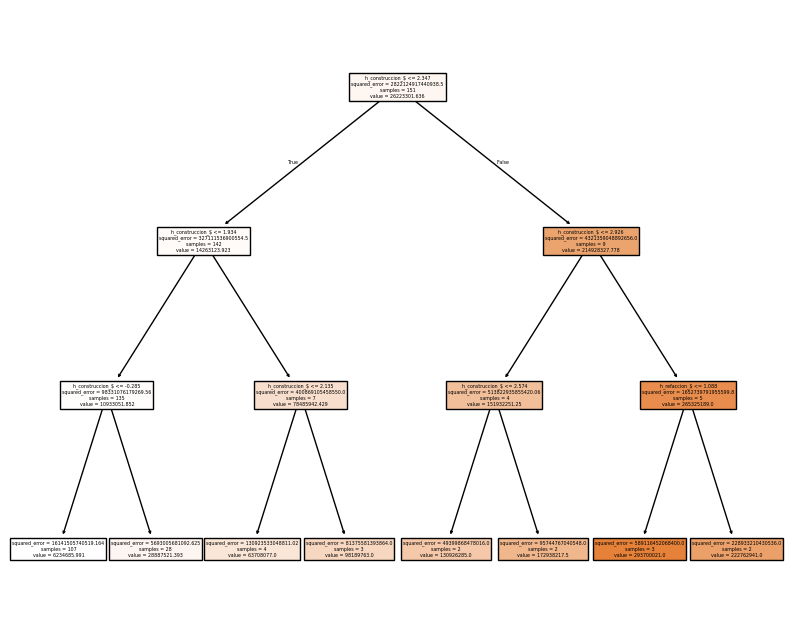

In [ ]:
# realizamos el grafico de arbol de deciones
plt.figure(figsize=(10, 8))
plot_tree(mejor_modelo_tree.estimators_[0], filled=True, feature_names=X.columns, class_names=y.columns)
plt.show()

# Etapa final
# Usamos K-means


In [ ]:
# usamos codigos anteriores y continuamos pero las dejo como comentario.

# Definimos nuetra variable regresora
#R = proyecto_df[['tipo_de_cambio','tasa_de_interes']]
# definimos nuetras variables objetivos en este caso las de los creditos
#q = proyecto_df[proyecto_tc]

In [ ]:
#Defino mi variable a trabajar
pro_kmean = proyecto_df[["tipo_de_cambio","tasa_de_interes"]]

In [ ]:
# Realizamos el escalado
scaler_kmean = StandardScaler()
pro_kmean_scaled = scaler_kmean.fit_transform(pro_kmean)

In [ ]:
# Entrenamiento de K-Means y seleccionamos tres escenarios
kmean = KMeans(n_clusters=3, random_state=42, n_init=10)
proyecto_df['cluster'] = kmean.fit_predict(pro_kmean_scaled)


In [ ]:
#escalomos los centroides
centroides_escalados = kmean.cluster_centers_
centroides_reales= scaler_kmean.inverse_transform(kmean.cluster_centers_)

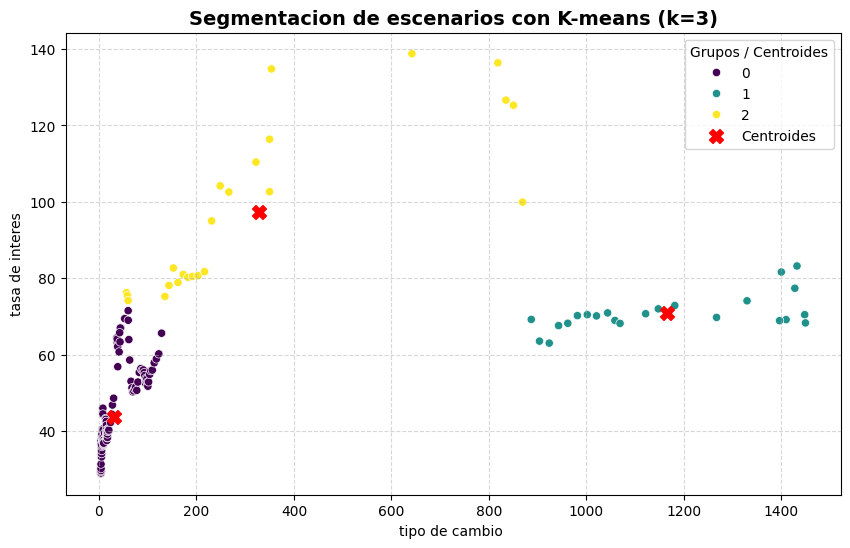

In [ ]:
# graficos
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='tipo_de_cambio',
    y='tasa_de_interes',
    hue='cluster',
    data=proyecto_df,
    palette='viridis'
    )

# Dibujamos los Centorides en cada escenario
plt.scatter(
    centroides_reales[:, 0],
    centroides_reales[:, 1],
    marker='X',
    c='red',
    s=100,
    label='Centroides'
)
plt.title("Segmentacion de escenarios con K-means (k=3)", fontsize=14, fontweight='bold')
plt.xlabel("tipo de cambio ")
plt.ylabel("tasa de interes")
plt.legend(title="Grupos / Centroides")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# Simulamos el proyecto con datos nuevos
nuevo_datos_escenario = {
    'tipo_de_cambio': 1300,
    'tasa_de_interes':70.0
}
nuevo_escenario = pd.DataFrame([nuevo_datos_escenario])
# Escalamos
nuevo_escenario_scaled = scaler_kmean.transform(nuevo_escenario)

# El modelo clacula a que cluster pertenece el nuevo

cluster_asignado = kmean.predict(nuevo_escenario_scaled)[0]

print(f"Escenario Evaluado: Tipo de cambio: ${nuevo_datos_escenario['tipo_de_cambio']} | Tasa de interes: {nuevo_datos_escenario['tasa_de_interes']}%")
print(f"Demanda Proyectada de Créditos por Línea:")
print("-" * 60)
if cluster_asignado == 0:
    print(" ESCENARIO ESTABLE: Tasas bajas, tipo de cambio controlado")
    print("ACCION: Luz verde para colocar prestamos")

elif cluster_asignado == 1:
    print("ESCENARIO VOLATIL: Tasas medias, tipo de cambio subiendo")
    print("ACCION: Luiz amarilla, ajustar plazos")
else:
    print("ESCENARIO DE RIESGO: Tasas altas, devaluacion acelerada. ")
    print("ACCION: Luz roja, restringir prestamos por riesgo de pago")

Escenario Evaluado: Tipo de cambio: $1300 | Tasa de interes: 75.0%
Demanda Proyectada de Créditos por Línea:
------------------------------------------------------------
ESCENARIO VOLATIL: Tasas medias, tipo de cambio subiendo
ACCION: Luiz amarilla, ajustar plazos


# Cualquier recomendacion es bienvenida
Saludos